In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://stip.oecd.org/assets/downloads/STIP_Survey.xlsx"

In [3]:
# load the dataset from OECD STIP Survey
stip_survey = pd.read_excel(url, engine="openpyxl")

In [6]:
# TH23 is the code for high rigk high reward research theme
stip_survey["TH23"] = stip_survey["TH23"].apply(pd.to_numeric, errors='coerce') # Ensure theme column is numeric

In [7]:
# select high risk high reward research - TH23
hrhr = stip_survey[stip_survey["TH23"] == 1] # if 1, theme is relevant; if 0, theme is not relevant for that initiative
len(hrhr)

161

### <h3 align= "center">Time-Series Analysis</h3>

In [8]:
# as it's one row per instrument type and an initiative can have several, will have to deduplicate
hrhr_initiatives = hrhr.drop_duplicates(subset=["InitiativeID"]).sort_values(by=["StartDateYear"])
len(hrhr_initiatives)

101

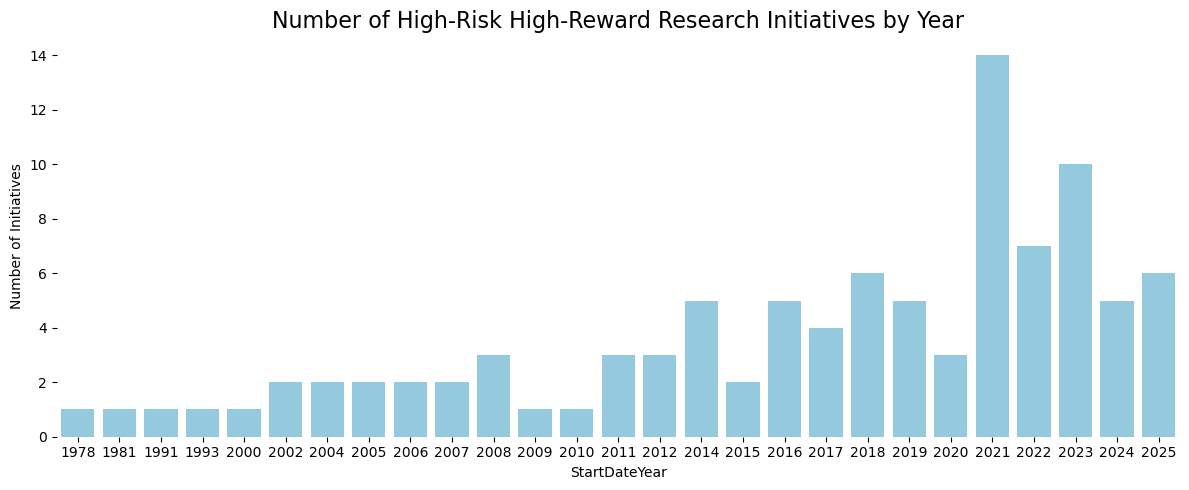

In [9]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=hrhr_initiatives,
    x='StartDateYear',
    color='skyblue',
)
sns.despine(left=True, bottom=True) # remove line layout to keep tidy
plt.title('Number of High-Risk High-Reward Research Initiatives by Year', fontsize=16)
plt.ylabel('Number of Initiatives')
plt.tight_layout() # to avoid overlapping on the x axis
#plt.show()

<h3 align="center">  Instrument Analysis </h3>

#### Which instrument types have been used in high-risk high-reward research initiatives and how frequently?

In [10]:
# identify the columns starting with 'F', which is a marker for an instrument column
instrument_cols = hrhr.columns[hrhr.columns.str.startswith('F')]
# ensure they are numeric
hrhr[instrument_cols] = hrhr[instrument_cols].apply(pd.to_numeric, errors='coerce')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9852\106943487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hrhr[instrument_cols] = hrhr[instrument_cols].apply(pd.to_numeric, errors='coerce')


In [11]:
# remove instrument columns that weren't used for high-risk high-reward research theme
used_instruments = instrument_cols[hrhr[instrument_cols].sum() > 0] # if sum of col is > 0 then instrument is used at least once for the theme
instruments_to_drop = instrument_cols[hrhr[instrument_cols].sum() == 0] # if sum of col is 0 then instrument is not used at all for the theme
hrhr_instruments = hrhr.drop(columns=instruments_to_drop)
hrhr_instruments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161 entries, 28 to 12587
Columns: 230 entries, InitiativeID to F99:V677
dtypes: float64(1), int64(94), object(135)
memory usage: 290.6+ KB


In [12]:
hrhr_long = hrhr_instruments.melt(
    # keep as ids every column except used instruments
    id_vars=[col for col in hrhr_instruments.columns if col not in used_instruments],
    value_vars=used_instruments,
    var_name='Instrument',
    value_name='value'
)
len(hrhr_long)

15134

In [13]:
# exclude instruments that weren't used on individual initiatives and keep only one type of instrument for each initiative
hrhr_used_instruments = hrhr_long[hrhr_long["value"] > 0].drop_duplicates(subset=['InitiativeID', 'InstrumentTypeLabel'])
len(hrhr_used_instruments)

115

In [14]:
# identify the frequency of instrument types for high-risk high-rewards research
instrument_counts = hrhr_used_instruments.groupby('InstrumentTypeLabel').size().reset_index(name='n').sort_values(by="n", ascending=False)
instrument_counts

,InstrumentTypeLabel,n
7,Project grants for public research,56
9,"Strategies, agendas and plans",16
3,Grants for business R&D and innovation,15
0,Centres of excellence grants,8
2,Fellowships and postgraduate loans and scholar...,8
5,Institutional funding for public research,5
1,Dedicated support to research and technical in...,3
6,Networking and collaborative platforms,2
4,Innovation vouchers,1
8,Science and technology regulation and soft law,1


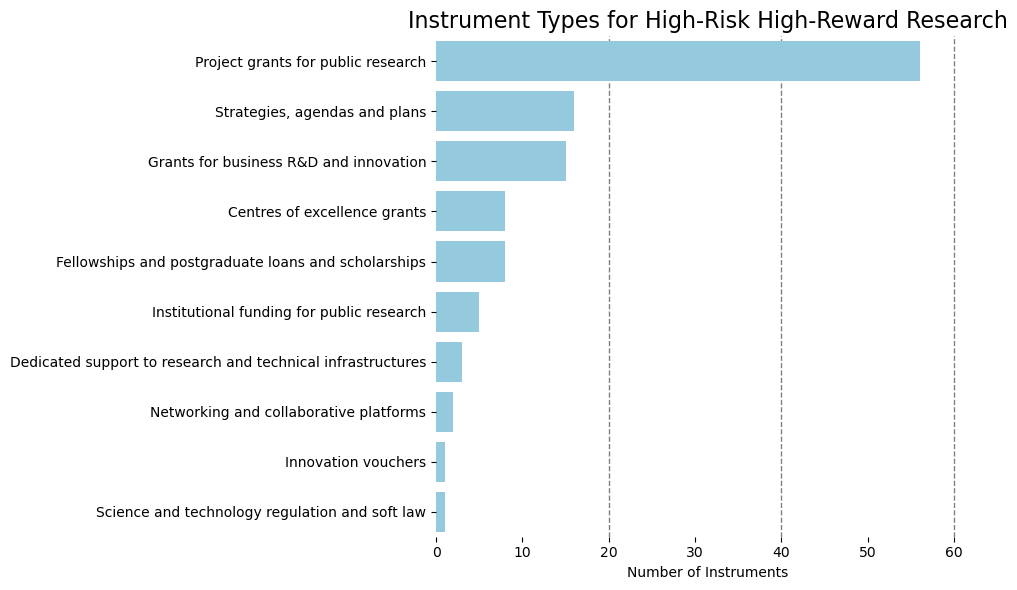

In [15]:
# plot the results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=instrument_counts,
    y='InstrumentTypeLabel',
    x='n',
    color='skyblue'
)
for x in [20, 40, 60]:
    plt.axvline(x, color='gray', linestyle='--', lw=1, zorder=0)
sns.despine(left=True, bottom=True)
plt.title('Instrument Types for High-Risk High-Reward Research', fontsize=16)
plt.xlabel('Number of Instruments')

plt.ylabel('')
plt.tight_layout()
plt.show()

#### What's the budget allocation for each instrument type used in high-risk high-reward research initiatives?

In [16]:
# because multiple instruments can be used in an initiative and we can't distinguish how much funding was allocated through individual instruments
# use weights to split the total funding by the number of distinct InstrementTypeLabel for the same initiative ID
distinct_counts = hrhr_used_instruments.groupby('InitiativeID')['InstrumentTypeLabel'].transform('nunique')

In [17]:
# Create the weight value: 1 divided by the number of unique instrument types
hrhr_used_instruments['weights'] = 1 / distinct_counts

In [18]:
# sum the weights per instrument type per budget rance
pivot_table = hrhr_used_instruments.pivot_table(
    index='InstrumentTypeLabel', 
    columns='YearlyBudgetRange', 
    values='weights', 
    aggfunc='sum'
).fillna(0)

In [19]:
budgets_order = ["Less than 1M", "1M-5M", "5M-20M", "20M-50M", "50M-100M", "100M-500M", "More than 500M", "Not applicable", "Unknown"]
instrument_order = pivot_table.sum(axis=1).sort_values(ascending=False).index
to_plot_ordered = pivot_table.reindex(index=instrument_order, columns=budgets_order)

Text(0.5, 1.0, 'Instrument Types for High-Risk High-Reward Research')

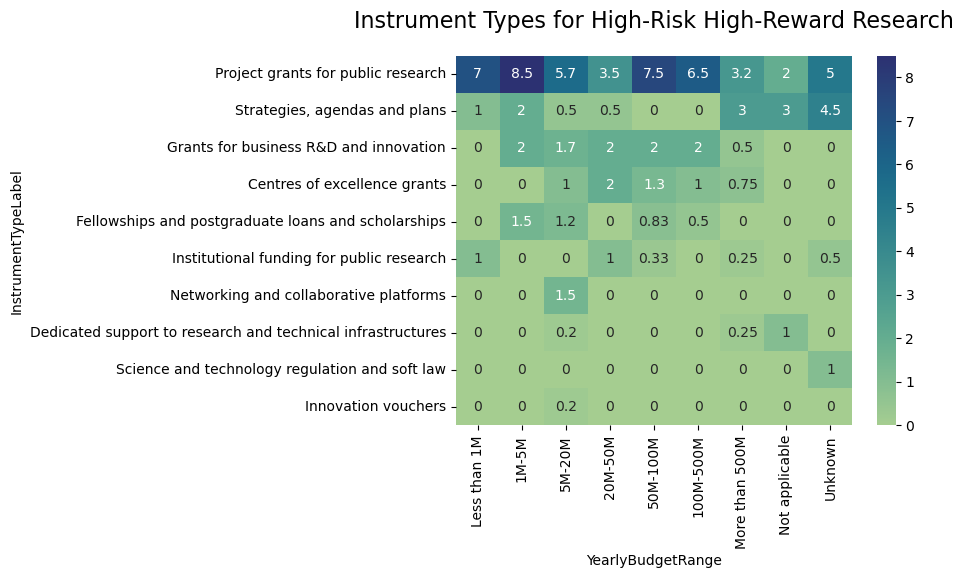

In [20]:
sns.heatmap(to_plot_ordered, cmap="crest", annot=True)
plt.title('Instrument Types for High-Risk High-Reward Research', fontsize=16, pad=20)